In [1]:
import numpy as np
import cloudvolume
from tqdm import tqdm
import glob
import os
import json

/Users/wangchu/opt/anaconda3/lib/python3.8/site-packages/python_jsonschema_objects/__init__.py:113: UserWarning: Schema id not specified. Defaulting to 'self'
  warnings.warn("Schema id not specified. Defaulting to 'self'")


In [2]:
em_seg_batch_paths = [
    [   # mrgd dataset .. ignore
        "precomputed://gs://htem_dorsalhorn_mrgd_r1093/dorsal_sections/dorsal_sections_0-500",
        "graphene://https://cave.fanc-fly.com/segmentation/table/mouse_dorsal_spine"
    ],
    [   # spinal-cord dataset
        "precomputed://gs://lee-mouse-spinal-cord-001-raw/sharded",
        "graphene://https://cave.fanc-fly.com/segmentation/table/wclee_mouse_spinalcord_cltmr"
    ]
]

DATASET_IDX = 1
MIP = (32,32,45)

em_path = em_seg_batch_paths[DATASET_IDX][0]
seg_path = em_seg_batch_paths[DATASET_IDX][1]

spinalcord_em = cloudvolume.CloudVolume(em_path, use_https=True, 
                                  fill_missing=True,
                                  mip=MIP,
                                  progress=False)
# SEG
spinalcord_seg = cloudvolume.CloudVolume(seg_path, 
                                   use_https=True, #secrets='REPLACE_WITH_YOUR_CAVE_TOKEN', 
                                   mip=MIP, 
                                   agglomerate=True, # for rootids
                                   progress=False)


In [3]:
def get_seg_id_from_coord(coord, seg_mip=(32,32,45), coordinate_mip=(32,32,45)):

    mip_scale = np.array(seg_mip)/np.array(coordinate_mip)
    seg_coord = (coord[0]//mip_scale[0], coord[1]//mip_scale[1], coord[2]//mip_scale[2])
    
    voxel_seg_id = spinalcord_seg[seg_coord] # segmentation ID of neuron coordinate
    return voxel_seg_id

In [4]:
import pandas as pd
from pathlib import Path
import re

# === Setup ===
folder_path = Path('/Users/wangchu/v3/v4/v4_gnn/v4_gnn')

# Define all cell types you want columns for (include low_confidence_sensory)
cell_types = ['Aδ-HTMR', 'C-Cold', 'C-HTMR', 'C-HTMR-Non-peptidergic',
              'C-Heat', 'N/A', 'Aβ-LTMR', 'Aδ-LTMR', 'C-LTMR', 'low_confidence_sensory']

# Classifier columns used to assess low-confidence sensory identity
classifier_column = ['cltmr', 'abltmr', 'adltmr', 'chtmrnp',
                   'c-htmr', 'adhtmrp', 'cheat', 'cold']

# Regex pattern to extract coordinates from filename
pattern = re.compile(r'cell_type_predictions_(\d+)_(\d+)_(\d+)\.feather')

# === Build rows ===
rows = []

for feather_file in folder_path.glob('cell_type_predictions_*.feather'):
    match = pattern.search(feather_file.name)
    if not match:
        continue

    x, y, z = map(int, match.groups())
    vol = get_seg_id_from_coord((x, y, z), seg_mip=(32, 32, 45), coordinate_mip=(32, 32, 45))
    root_id = int(vol[0, 0, 0, 0])

    df = pd.read_feather(feather_file)

    # Create mask for is_sensory == True
    is_sensory_mask = df['is_sensory'] == True

    # Create mask for all classifier values <= 0.9
    low_confidence_mask = (df[classifier_column] <= 0.6).all(axis=1)

    # Combine masks
    final_mask = is_sensory_mask & low_confidence_mask

    # Update 'cell_type' for those rows
    df.loc[final_mask, 'cell_type'] = 'low_confidence_sensory'
    # Step 2: Count cell_type occurrences
    synapse_counts = df['cell_type'].value_counts().to_dict()

    # Step 3: Build row for result_df
    row_data = {ct: synapse_counts.get(ct, 0) for ct in cell_types}
    row_data['neuron_id'] = root_id
    rows.append(row_data)

# === Create result_df ===
result_df = pd.DataFrame(rows).set_index('neuron_id')
print(result_df.head())

                    Aδ-HTMR  C-Cold  C-HTMR  C-HTMR-Non-peptidergic  C-Heat  \
neuron_id                                                                     
720575940905042134        8       7       1                      10      13   
720575940905121334        1       0       2                       6       3   
720575940882124516        2       0       0                      33       0   
720575940893395733       14       0       5                     778       8   
720575940940386475       15      34       3                       1      12   

                     N/A  Aβ-LTMR  Aδ-LTMR  C-LTMR  low_confidence_sensory  
neuron_id                                                                   
720575940905042134  2967        2        0       2                      14  
720575940905121334   991       70      419      46                      12  
720575940882124516   620        1        2     704                       7  
720575940893395733  1168        0        0      15           

In [5]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')
# Synapses df
cell_tag = client.materialize.query_table('spinalcord_neuron_clusters')

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

def plot_v1_v2_sensory_heatmap(result_df, cell_tag, save_svg_path=None,
                               fig_w_cm=4.3, fig_h_cm=12.0):
    # -----------------------------
    # Figure sizing (cm → inches)
    # -----------------------------
    cm_to_in = 1 / 2.54
    fig_w = fig_w_cm * cm_to_in
    fig_h = fig_h_cm * cm_to_in

    # -----------------------------
    # Build v1/v2 index from cell_tag
    # -----------------------------
    ct = cell_tag[['pt_root_id', 'tag']].dropna().copy()
    ct['tag'] = ct['tag'].astype(str).str.lower()
    ct = ct[ct['tag'].isin(['v1', 'v2'])]

    # If duplicates: prefer v1 over v2 for a root that has both
    vmap = (ct.groupby('pt_root_id')['tag']
              .agg(lambda s: 'v1' if 'v1' in set(s) else 'v2'))

    # Make sure result_df index type matches
    sub = result_df.copy()
    sub.index = sub.index.astype(np.int64)

    # Overlap of IDs
    common_ids = sub.index.intersection(vmap.index)
    if len(common_ids) == 0:
        raise ValueError("No overlap between result_df.index and cell_tag['pt_root_id'].")

    # Subset and attach group
    sub = sub.loc[common_ids].copy()
    sub['v_group'] = vmap.loc[common_ids].values

    # -----------------------------
    # Choose sensory columns (raw)
    # -----------------------------
    raw_cols = ['C-Cold', 'Aδ-HTMR', 'C-Heat', 'C-HTMR',
                'C-HTMR-Non-peptidergic', 'C-LTMR',
                'Aδ-LTMR', 'Aβ-LTMR', 'low_confidence_sensory']
    for c in raw_cols:
        if c not in sub.columns:
            sub[c] = 0

    # Optional renaming to match your labels
    rename_map = {
        'C-Heat': 'Peptidergic C-Nociceptors',
        'C-HTMR': 'SST',
        'low_confidence_sensory': 'Low-Confidence'
    }
    display_cols = ['C-Cold', 'Aδ-HTMR', 'Peptidergic C-Nociceptors', 'SST',
                    'C-HTMR-Non-peptidergic', 'C-LTMR', 'Aδ-LTMR', 'Aβ-LTMR', 'Low-Confidence']

    # -----------------------------
    # Build the plotting matrix (v1 then v2), row-normalized and sorted
    # -----------------------------
    def build_block(df_group):
        mat = df_group[raw_cols].rename(columns=rename_map)
        mat = mat[display_cols]
        # row-normalize
        mat = mat.div(mat.sum(axis=1), axis=0).fillna(0)
        # sort rows by dominant class then its value (descending)
        vals = mat.values
        dom_idx = np.argmax(vals, axis=1)
        dom_val = vals[np.arange(vals.shape[0]), dom_idx]
        order = (pd.DataFrame({'dom_idx': dom_idx, 'dom_val': dom_val}, index=mat.index)
                 .sort_values(['dom_idx', 'dom_val'], ascending=[True, False]).index)
        return mat.loc[order]

    v1_block = build_block(sub[sub['v_group'] == 'v1'])
    v2_block = build_block(sub[sub['v_group'] == 'v2'])
    normalized_matrix = pd.concat([v1_block, v2_block], axis=0)

    # -----------------------------
    # Heatmap
    # -----------------------------
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        normalized_matrix,
        cmap='Blues',
        yticklabels=False,
        xticklabels=True,
        cbar=False,
        ax=ax
    )

    # Red dashed line between v1 and v2
    v1_size = v1_block.shape[0]
    if v1_size > 0:
        ax.axhline(v1_size, color='red', linestyle='--', linewidth=1)

    # Format x-axis labels
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=5,
        fontname='Helvetica',
        rotation=-45,
        ha='left'
    )
    ax.set_title('Sensory composition → v1 and v2 (row-normalized)', fontsize=8)
    plt.tight_layout()

    # -----------------------------
    # Optional SVG save
    # -----------------------------
    if save_svg_path:
        p = Path(save_svg_path)
        # If user passed a directory (or a path without .svg), append a filename
        if p.suffix.lower() != '.svg':
            p = p / 'sensory_v1_v2_heatmap.svg'
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, format='svg', dpi=600, bbox_inches='tight')
        print(f"Saved SVG to: {p}")

    plt.show()
    return normalized_matrix  # handy for debugging or tests


Saved SVG to: /Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_sensory_input.svg


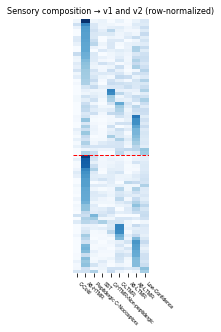

,C-Cold,Aδ-HTMR,Peptidergic C-Nociceptors,SST,C-HTMR-Non-peptidergic,C-LTMR,Aδ-LTMR,Aβ-LTMR,Low-Confidence
720575940865467295,0.029412,0.705882,0.029412,0.044118,0.000000,0.044118,0.000000,0.044118,0.102941
720575940878957108,0.148515,0.475248,0.108911,0.039604,0.029703,0.009901,0.009901,0.089109,0.089109
720575940909797811,0.047619,0.412698,0.111111,0.031746,0.063492,0.079365,0.031746,0.063492,0.158730
720575940899433773,0.000000,0.404040,0.141414,0.070707,0.202020,0.050505,0.020202,0.020202,0.090909
720575940920037245,0.000000,0.396825,0.111111,0.095238,0.095238,0.031746,0.063492,0.031746,0.174603
...,...,...,...,...,...,...,...,...,...
720575940886540578,0.005587,0.301676,0.011173,0.022346,0.039106,0.134078,0.027933,0.312849,0.145251
720575940882672796,0.049383,0.271605,0.024691,0.086420,0.012346,0.111111,0.012346,0.308642,0.123457
720575940885432678,0.016129,0.290323,0.129032,0.048387,0.000000,0.032258,0.016129,0.306452,0.161290
720575940880837650,0.019608,0.137255,0.019608,0.039216,0.137255,0.137255,0.098039,0.117647,0.294118


In [12]:
# Save to a specific file
plot_v1_v2_sensory_heatmap(result_df, cell_tag, save_svg_path="/Users/wangchu/connectivity_analysis/interneuron_matrix_figure4/v1_v2_sensory_input.svg")


